In [1]:
import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder exists: True


In [4]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {
            ".jpg", ".jpeg", ".png"
        }:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["label"].value_counts().sort_index())

Total images: 44000
label
0    12800
1    31200
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

development_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

development_df = development_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

print("Development images:", len(development_df))
print(development_df["label"].value_counts().sort_index())

print("\nTest images:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Development images: 37400
label
0    10880
1    26520
Name: count, dtype: int64

Test images: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_dataset(
    dataframe,
    training=False,
    shuffle_seed=SEED
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                10000
            ),
            seed=shuffle_seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


test_dataset = create_dataset(test_df)

for images, labels in test_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

I0000 00:00:1787583795.362759      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [7]:
from sklearn.model_selection import StratifiedKFold

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001
N_FOLDS = 5

cross_validator = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    print(
        f"Fold {fold}: "
        f"Training = {len(train_indices)}, "
        f"Validation = {len(validation_indices)}"
    )

Fold 1: Training = 29920, Validation = 7480
Fold 2: Training = 29920, Validation = 7480
Fold 3: Training = 29920, Validation = 7480
Fold 4: Training = 29920, Validation = 7480
Fold 5: Training = 29920, Validation = 7480


In [8]:
def build_mobilenetv2(fold_seed):
    tf.keras.utils.set_random_seed(
        fold_seed
    )

    augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(
            0.05,
            0.05
        )
    ])

    mobilenet_base = (
        tf.keras.applications.MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    )

    mobilenet_base.trainable = False

    inputs = tf.keras.Input(
        shape=(224, 224, 3)
    )

    x = augmentation(inputs)

    x = (
        tf.keras.applications.mobilenet_v2
        .preprocess_input(x)
    )

    x = mobilenet_base(
        x,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="MobileNetV2_Binary"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [9]:
from sklearn.utils.class_weight import (
    compute_class_weight
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

fold_histories = {}
fold_results = []
fold_test_probabilities = []

print("Cross-validation storage initialized.")

Cross-validation storage initialized.


In [10]:
for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    print(f"\n{'=' * 20} FOLD {fold}/5 {'=' * 20}")

    fold_train_df = development_df.iloc[
        train_indices
    ].reset_index(drop=True)

    fold_validation_df = development_df.iloc[
        validation_indices
    ].reset_index(drop=True)

    train_dataset = create_dataset(
        fold_train_df,
        training=True,
        shuffle_seed=SEED + fold
    )

    validation_dataset = create_dataset(
        fold_validation_df
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=fold_train_df["label"]
    )

    fold_class_weights = {
        0: float(weights[0]),
        1: float(weights[1])
    }

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_mobilenetv2(
        SEED + fold
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=MAX_EPOCHS,
        class_weight=fold_class_weights,
        callbacks=callbacks,
        verbose=1
    )

    training_minutes = (
        time.time() - start_time
    ) / 60

    fold_history = pd.DataFrame(
        history.history
    )

    fold_histories[fold] = fold_history

    best_index = fold_history[
        "val_loss"
    ].idxmin()

    validation_probabilities = model.predict(
        validation_dataset,
        verbose=0
    ).ravel()

    validation_labels = fold_validation_df[
        "label"
    ].to_numpy()

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    fold_results.append({
        "Fold": fold,
        "Epochs Trained": len(fold_history),
        "Best Epoch": best_index + 1,

        "Training Loss": fold_history.loc[
            best_index,
            "loss"
        ],

        "Training Accuracy": fold_history.loc[
            best_index,
            "accuracy"
        ],

        "Validation Loss": fold_history.loc[
            best_index,
            "val_loss"
        ],

        "Validation Accuracy": fold_history.loc[
            best_index,
            "val_accuracy"
        ],

        "Precision": precision_score(
            validation_labels,
            validation_predictions
        ),

        "Recall": recall_score(
            validation_labels,
            validation_predictions
        ),

        "F1-score": f1_score(
            validation_labels,
            validation_predictions
        ),

        "ROC-AUC": roc_auc_score(
            validation_labels,
            validation_probabilities
        ),

        "Training Minutes": training_minutes
    })

    fold_test_probabilities.append(
        model.predict(
            test_dataset,
            verbose=0
        ).ravel()
    )

    print(
        f"Fold {fold} completed in "
        f"{training_minutes:.2f} minutes"
    )

    del model
    gc.collect()


==================== FOLD 1/5 ====================
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 127s 128ms/step - accuracy: 0.5796 - loss: 0.6904 - val_accuracy: 0.5989 - val_loss: 0.6592 - learning_rate: 1.0000e-04
Epoch 2/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.6882 - loss: 0.5878 - val_accuracy: 0.6291 - val_loss: 0.6460 - learning_rate: 1.0000e-04
Epoch 3/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.7196 - loss: 0.5558 - val_accuracy: 0.6757 - val_loss: 0.6036 - learning_rate: 1.0000e-04
Epoch 4/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.7358 - loss: 0.5383 - val_accuracy: 0.6845 - val_loss: 0.5975 - learning_rate: 1.0000e-04
Epoch 5/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.7436 - loss: 0.5295 - val_accuracy: 0.6878 - val_loss: 0.5934 - learning_rate: 1.0000e-04
Epoch 6/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - accuracy: 0.7535 - loss: 0.5161 - val_accuracy: 0.6

In [11]:
fold_results_df = pd.DataFrame(
    fold_results
)

display(
    fold_results_df.round(4)
)

,Fold,Epochs Trained,Best Epoch,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Minutes
0,1,14,9,0.5016,0.7603,0.5348,0.7330,0.9194,0.6834,0.7840,0.8578,11.9723
1,2,16,11,0.5034,0.7588,0.5835,0.7015,0.9271,0.6284,0.7491,0.8496,12.2385
2,3,6,1,0.6888,0.6017,0.5556,0.7377,0.8323,0.7890,0.8101,0.7700,4.6823
3,4,22,17,0.4934,0.7630,0.5622,0.7106,0.9252,0.6439,0.7593,0.8588,16.9456
4,5,14,9,0.5213,0.7465,0.5877,0.6956,0.9229,0.6227,0.7437,0.8417,10.8971


In [12]:
summary_columns = [
    "Training Loss",
    "Training Accuracy",
    "Validation Loss",
    "Validation Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

cv_summary_df = pd.DataFrame({
    "Mean": fold_results_df[
        summary_columns
    ].mean(),

    "Standard Deviation": fold_results_df[
        summary_columns
    ].std()
})

display(
    cv_summary_df.round(4)
)

,Mean,Standard Deviation
Training Loss,0.5417,0.0828
Training Accuracy,0.7261,0.0698
Validation Loss,0.5648,0.0216
Validation Accuracy,0.7157,0.0188
Precision,0.9054,0.0409
Recall,0.6735,0.0688
F1-score,0.7692,0.0276
ROC-AUC,0.8356,0.0373


In [13]:
test_probabilities_cv = np.mean(
    np.vstack(
        fold_test_probabilities
    ),
    axis=0
)

test_predictions_cv = (
    test_probabilities_cv >= 0.5
).astype(int)

true_test_labels = test_df[
    "label"
].to_numpy()

print("Test images:", len(true_test_labels))
print(
    "Ensemble predictions:",
    len(test_predictions_cv)
)

Test images: 6600
Ensemble predictions: 6600


In [14]:
from sklearn.metrics import (
    log_loss,
    accuracy_score
)

test_loss_cv = log_loss(
    true_test_labels,
    test_probabilities_cv
)

test_accuracy_cv = accuracy_score(
    true_test_labels,
    test_predictions_cv
)

print(
    "Test Loss:",
    round(test_loss_cv, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy_cv, 4)
)

Test Loss: 0.5486
Test Accuracy: 0.7235


In [15]:
test_precision_cv = precision_score(
    true_test_labels,
    test_predictions_cv
)

test_recall_cv = recall_score(
    true_test_labels,
    test_predictions_cv
)

test_f1_cv = f1_score(
    true_test_labels,
    test_predictions_cv
)

test_auc_cv = roc_auc_score(
    true_test_labels,
    test_probabilities_cv
)

print(
    "Precision:",
    round(test_precision_cv, 4)
)

print(
    "Recall:",
    round(test_recall_cv, 4)
)

print(
    "F1-score:",
    round(test_f1_cv, 4)
)

print(
    "ROC-AUC:",
    round(test_auc_cv, 4)
)

Precision: 0.9158
Recall: 0.6718
F1-score: 0.7751
ROC-AUC: 0.8528


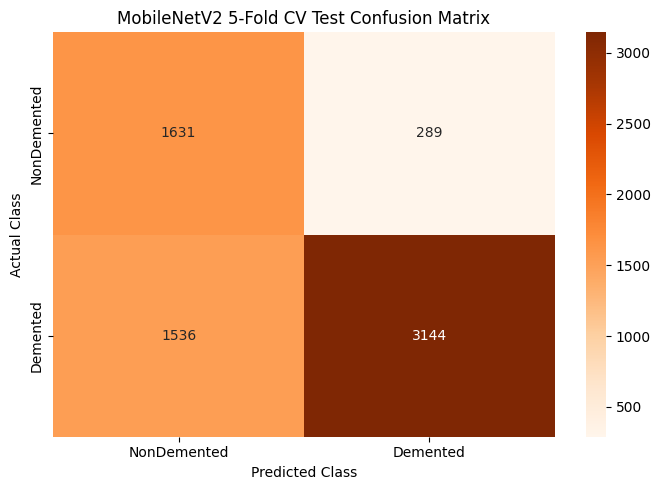

In [16]:
from sklearn.metrics import confusion_matrix

cm_cv = confusion_matrix(
    true_test_labels,
    test_predictions_cv
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_cv,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=[
        "NonDemented",
        "Demented"
    ],
    yticklabels=[
        "NonDemented",
        "Demented"
    ]
)

plt.title(
    "MobileNetV2 5-Fold CV Test Confusion Matrix"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

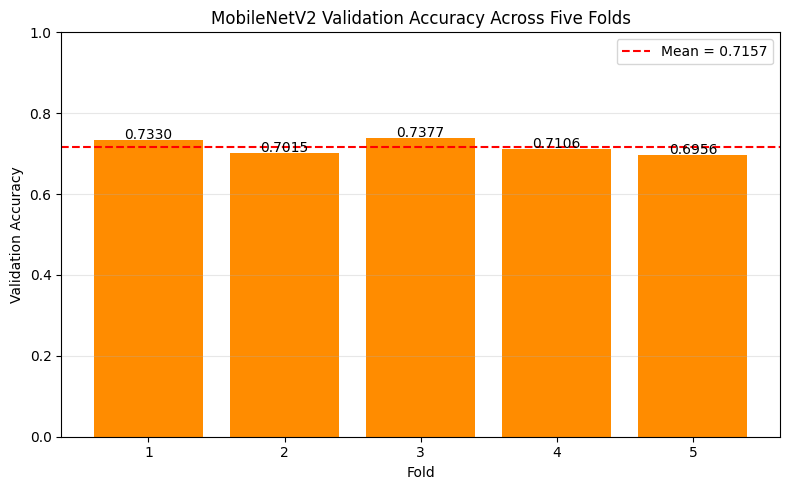

In [17]:
mean_validation_accuracy = (
    fold_results_df[
        "Validation Accuracy"
    ].mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    fold_results_df["Fold"],
    fold_results_df[
        "Validation Accuracy"
    ],
    color="darkorange"
)

plt.axhline(
    mean_validation_accuracy,
    color="red",
    linestyle="--",
    label=(
        f"Mean = "
        f"{mean_validation_accuracy:.4f}"
    )
)

for bar, value in zip(
    bars,
    fold_results_df[
        "Validation Accuracy"
    ]
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.003,
        f"{value:.4f}",
        ha="center"
    )

plt.ylim(0, 1)
plt.title(
    "MobileNetV2 Validation Accuracy Across Five Folds"
)
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.xticks(fold_results_df["Fold"])
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

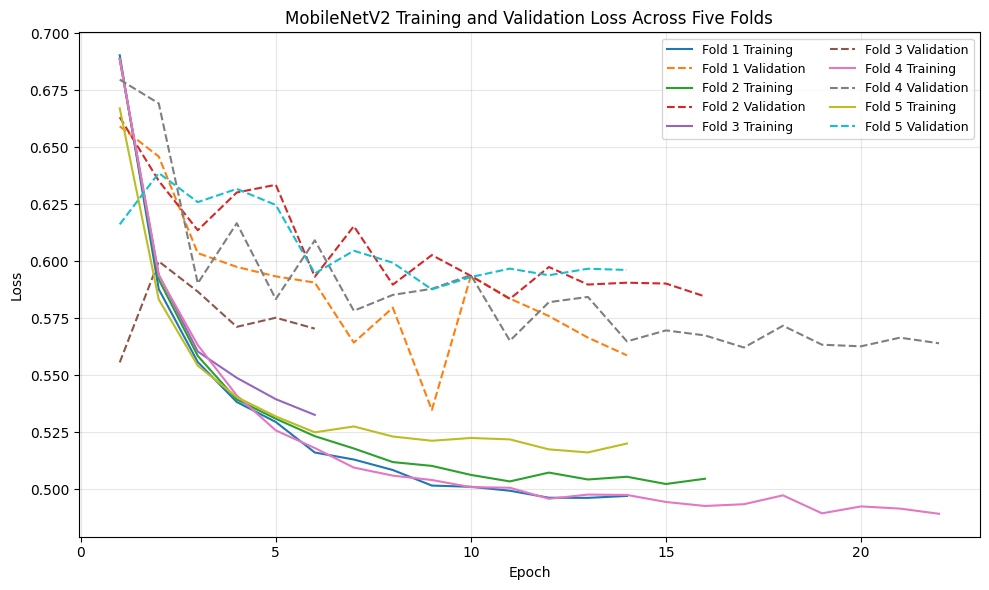

In [18]:
plt.figure(figsize=(10, 6))

for fold, fold_history in fold_histories.items():
    epochs = range(
        1,
        len(fold_history) + 1
    )

    plt.plot(
        epochs,
        fold_history["loss"],
        label=f"Fold {fold} Training"
    )

    plt.plot(
        epochs,
        fold_history["val_loss"],
        linestyle="--",
        label=f"Fold {fold} Validation"
    )

plt.title(
    "MobileNetV2 Training and Validation Loss Across Five Folds"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

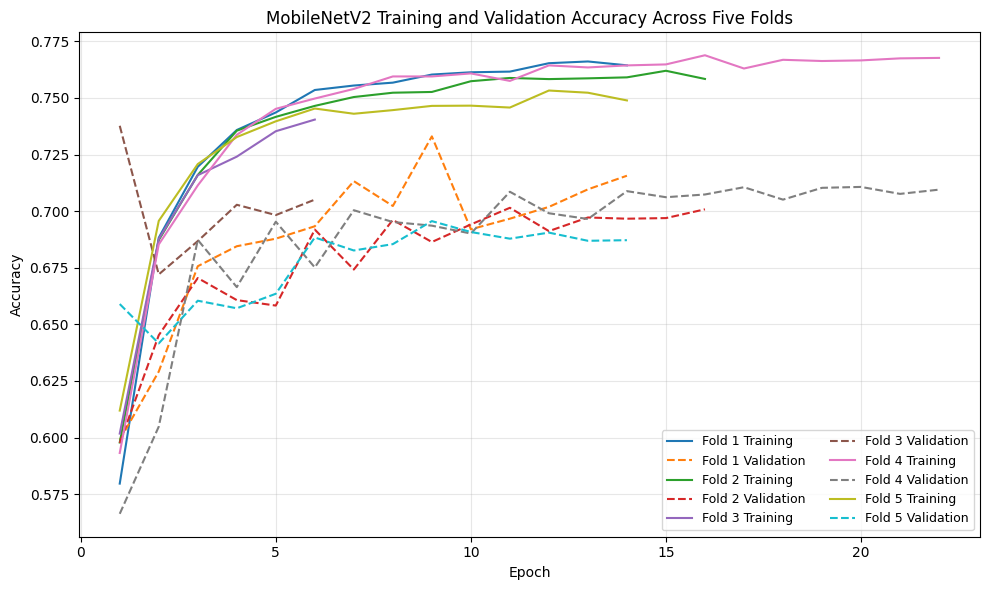

In [19]:
plt.figure(figsize=(10, 6))

for fold, fold_history in fold_histories.items():
    epochs = range(
        1,
        len(fold_history) + 1
    )

    plt.plot(
        epochs,
        fold_history["accuracy"],
        label=f"Fold {fold} Training"
    )

    plt.plot(
        epochs,
        fold_history["val_accuracy"],
        linestyle="--",
        label=f"Fold {fold} Validation"
    )

plt.title(
    "MobileNetV2 Training and Validation Accuracy Across Five Folds"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

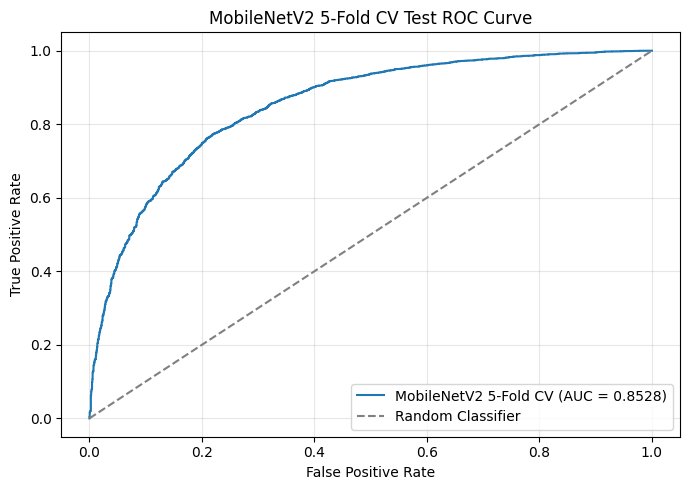

In [20]:
from sklearn.metrics import roc_curve

fpr_cv, tpr_cv, _ = roc_curve(
    true_test_labels,
    test_probabilities_cv
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_cv,
    tpr_cv,
    label=(
        f"MobileNetV2 5-Fold CV "
        f"(AUC = {test_auc_cv:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title(
    "MobileNetV2 5-Fold CV Test ROC Curve"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

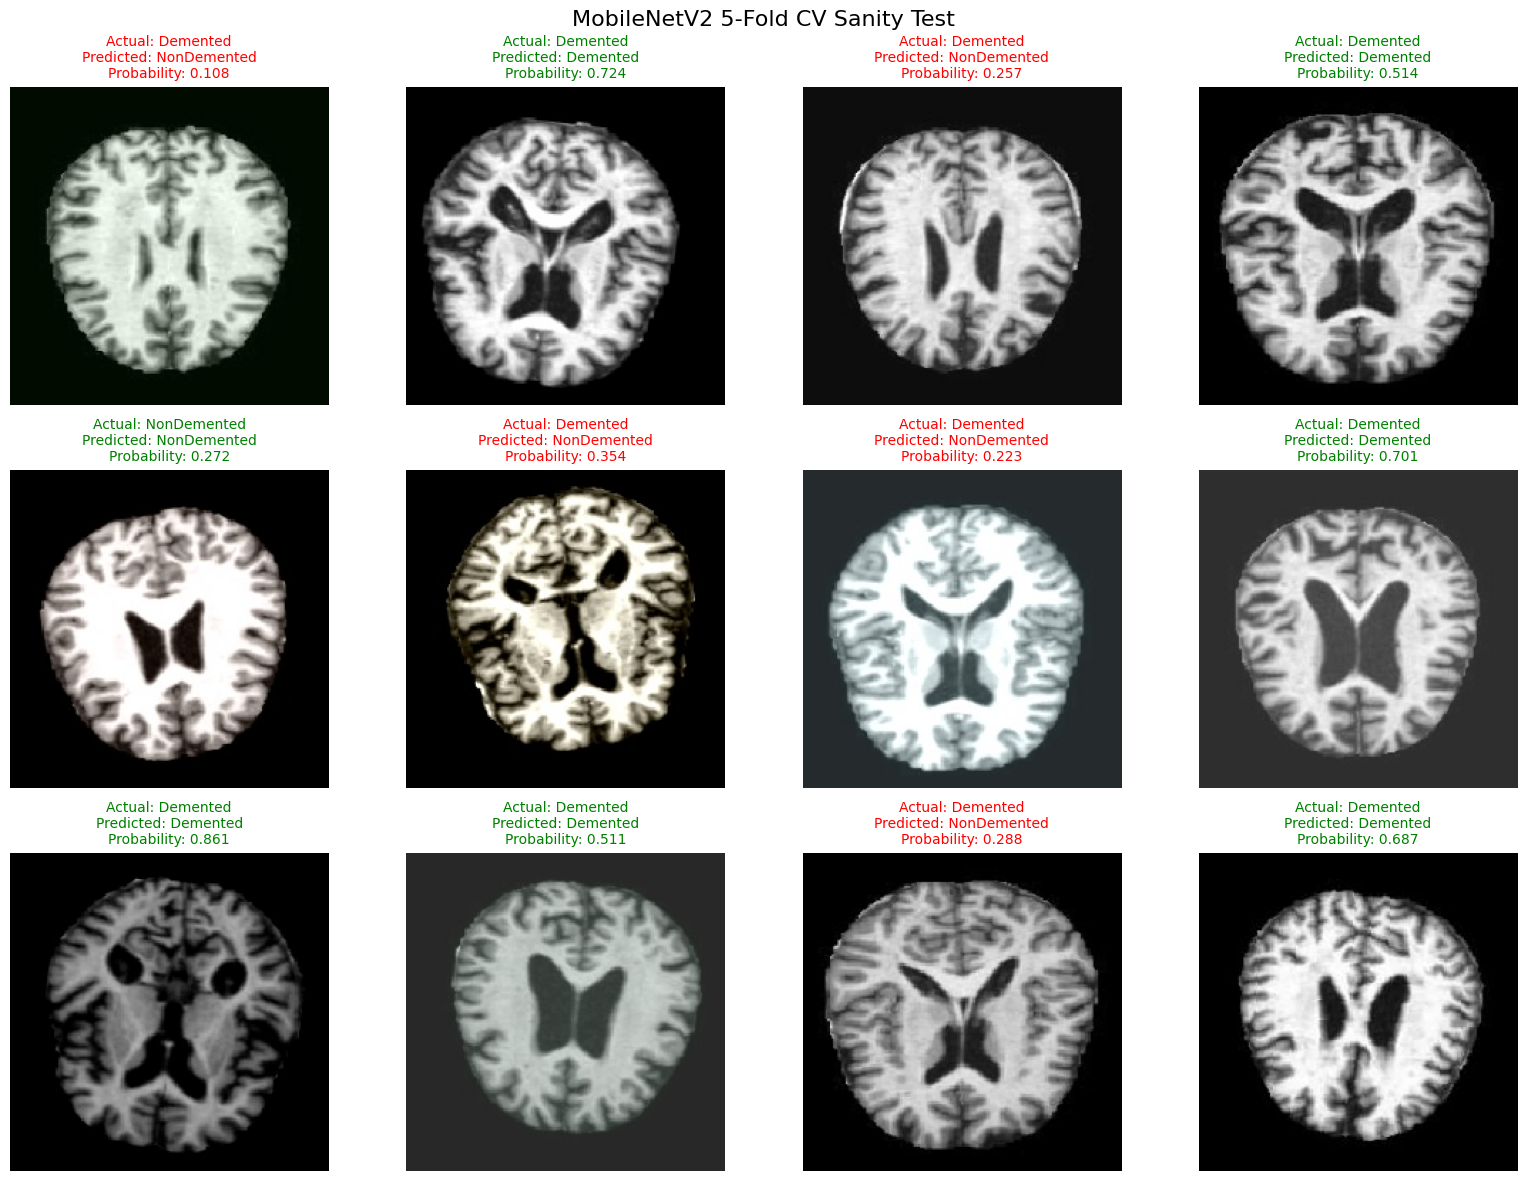

In [21]:
sample_indices = np.random.default_rng(
    SEED
).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(
    sample_indices,
    start=1
):
    image = tf.keras.utils.load_img(
        test_df.iloc[index]["filepath"],
        target_size=IMG_SIZE
    )

    actual = true_test_labels[index]
    predicted = test_predictions_cv[index]
    probability = test_probabilities_cv[index]

    actual_name = (
        "Demented"
        if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented"
        if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green"
        if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(image)

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "MobileNetV2 5-Fold CV Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [22]:
test_results_df = pd.DataFrame({
    "Model": ["MobileNetV2"],
    "Cross-Validation": ["5-Fold"],
    "Test Loss": [test_loss_cv],
    "Accuracy": [test_accuracy_cv],
    "Precision": [test_precision_cv],
    "Recall": [test_recall_cv],
    "F1-score": [test_f1_cv],
    "ROC-AUC": [test_auc_cv]
})

all_histories_df = pd.concat(
    [
        history.assign(
            Fold=fold,
            Epoch=range(
                1,
                len(history) + 1
            )
        )
        for fold, history
        in fold_histories.items()
    ],
    ignore_index=True
)

fold_results_df.to_csv(
    "/kaggle/working/mobilenetv2_cv_fold_results.csv",
    index=False
)

cv_summary_df.to_csv(
    "/kaggle/working/mobilenetv2_cv_summary.csv"
)

test_results_df.to_csv(
    "/kaggle/working/mobilenetv2_cv_test_results.csv",
    index=False
)

all_histories_df.to_csv(
    "/kaggle/working/mobilenetv2_cv_training_history.csv",
    index=False
)

display(
    test_results_df.round(4)
)

print(
    "All MobileNetV2 CV result files saved."
)

,Model,Cross-Validation,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,MobileNetV2,5-Fold,0.5486,0.7235,0.9158,0.6718,0.7751,0.8528


All MobileNetV2 CV result files saved.
